# Multi-Modal AI Systems Tutorial

Author: Lokesh Mohanty

## Table of Contents
1. Introduction to Multi-Modal AI
2. Vision-Language Models (VLMs)
3. Audio Models: ASR and TTS
4. CLIP: Connecting Vision and Text
5. Diffusion Models: DDPM and Stable Diffusion
6. Flow-Based Models

## Learning Objectives
- Understand the architecture and applications of multi-modal AI systems
- Explore Vision-Language Models and their capabilities
- Learn about Audio processing with ASR and TTS systems
- Implement CLIP for image-text understanding
- Understand diffusion models and their training process
- See practical examples of why models accept multiple input modalities

## Prerequisites
- Basic knowledge of deep learning
- Familiarity with PyTorch/TensorFlow
- Understanding of transformers architecture


In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install transformers diffusers --quiet
!pip install git+https://github.com/openai/whisper.git --quiet  # For ASR
!pip install pillow requests --quiet  # For image processing


import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done



---
## 1. Introduction to Multi-Modal AI

Multi-modal AI systems process and understand multiple types of data:
- Vision (images, videos)
- Language (text)
- Audio (speech, music, sounds)
- Other modalities (sensor data, time series)


Why Multi-Modal?
1. Human-like understanding requires multiple senses
2. Richer representations through cross-modal learning
3. Better generalization and robustness
4. Real-world applications demand multi-modal input


Key Challenges:
- Alignment between modalities
- Different data distributions and scales
- Computational complexity
- Training data requirements

---
## 2. Vision-Language Models bridge computer vision and natural language processing.

Popular VLM Architectures:
1. **CLIP** - Contrastive Language-Image Pre-training
2. **BLIP** - Bootstrapping Language-Image Pre-training
3. **FLAMINGO** - Few-shot learning with retrieval augmentation
4. **GPT-4V** - Multi-modal GPT
5. **LLaVA** - Large Language and Vision Assistant

Key Applications:
- Image captioning
- Visual question answering (VQA)
- Image-text retrieval
- Zero-shot image classification

**References**:
- [CLIP](https://openai.com/index/clip/)
<img src='https://images.ctfassets.net/kftzwdyauwt9/fbc4f633-9ad4-4dc2-3809c22df5e0/0bd2d5abf90d052731538613e4a42668/overview-a.svg' width="500">

- [BLIP](https://ahmed-sabir.medium.com/paper-summary-blip-bootstrapping-language-image-pre-training-for-unified-vision-language-c1df6f6c9166)
<img src='https://miro.medium.com/v2/resize:fit:1160/format:webp/1*9gzL-3ikQNKgyaN1X9ZFuw.png'>

---
### CLIP


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


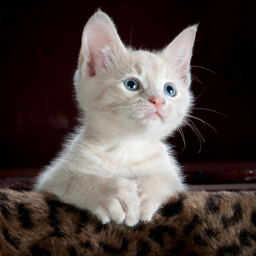

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

img_url = 'https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg'
image = Image.open(requests.get(img_url, stream=True).raw).resize((256, 256))
display(image)


In [ ]:
captions = [
    "A photo of a dog",
    "A photo of a cat",
    "A photo of code on a screen",
]
inputs = clip_processor(text=captions, images=image, return_tensors="pt", padding=True)
outputs = clip_model(**inputs)
probs = outputs.logits_per_image.softmax(dim=1)
for cap, p in zip(captions, probs[0]):
    print(f"{cap}: {p.item():.3f}")

A photo of a dog: 0.002
A photo of a cat: 0.992
A photo of code on a screen: 0.006


---
### BLIP

Loading BLIP model for image captioning...
Generated Caption: a kitten sitting on a blanket


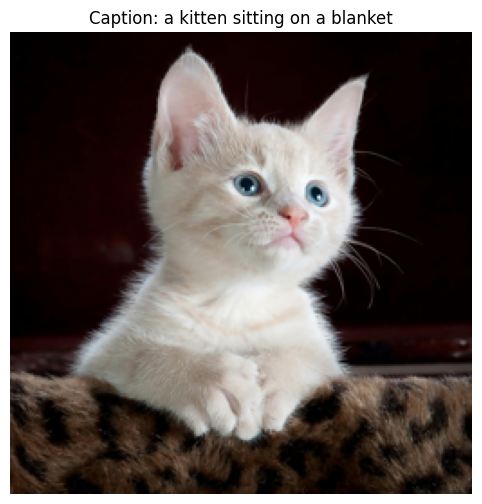

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import pipeline

# Load BLIP model for image captioning
print("Loading BLIP model for image captioning...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Process image
inputs = blip_processor(image, return_tensors="pt")

# Generate caption
out = blip_model.generate(**inputs, max_length=50)
caption = blip_processor.decode(out[0], skip_special_tokens=True)

print(f"Generated Caption: {caption}")

# Display image (if in notebook environment)
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"Caption: {caption}")
plt.axis('off')
plt.show()

---
### VLM Architecture Example

In [ ]:
class SimpleVLM(nn.Module):
    """
    Simplified Vision-Language Model architecture
    """
    def __init__(self, vocab_size=10000, hidden_dim=512):
        super(SimpleVLM, self).__init__()

        # Vision encoder (simplified CNN)
        self.vision_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((7, 7)),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, hidden_dim)
        )

        # Text encoder (simplified)
        self.text_embedding = nn.Embedding(vocab_size, hidden_dim)
        self.text_encoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)

        # Cross-modal attention
        self.cross_attention = nn.MultiheadAttention(hidden_dim, 8, batch_first=True)

        # Output heads
        self.caption_head = nn.Linear(hidden_dim, vocab_size)
        self.similarity_head = nn.Linear(hidden_dim * 2, 1)

    def forward(self, images, text_tokens=None, task='caption'):
        # Encode image
        img_features = self.vision_encoder(images)  # [batch, hidden_dim]

        if task == 'caption' and text_tokens is not None:
            # Text encoding for captioning
            text_emb = self.text_embedding(text_tokens)
            text_features, _ = self.text_encoder(text_emb)

            # Cross-attention between image and text
            attended_features, _ = self.cross_attention(
                text_features,
                img_features.unsqueeze(1).expand(-1, text_features.size(1), -1),
                img_features.unsqueeze(1).expand(-1, text_features.size(1), -1)
            )

            # Generate next tokens
            output = self.caption_head(attended_features)
            return output

        elif task == 'similarity' and text_tokens is not None:
            # Compute image-text similarity
            text_emb = self.text_embedding(text_tokens)
            text_features, _ = self.text_encoder(text_emb)
            text_features = text_features.mean(dim=1)  # Average pooling

            combined = torch.cat([img_features, text_features], dim=1)
            similarity = torch.sigmoid(self.similarity_head(combined))
            return similarity

        return img_features

# Demonstrate the custom VLM
vlm_model = SimpleVLM()
print(f"Custom VLM created with {sum(p.numel() for p in vlm_model.parameters())} parameters")

# Example forward pass
batch_size = 2
dummy_images = torch.randn(batch_size, 3, 224, 224)
dummy_text = torch.randint(0, 1000, (batch_size, 20))

img_features = vlm_model(dummy_images)
similarity_scores = vlm_model(dummy_images, dummy_text, task='similarity')

print(f"Image features shape: {img_features.shape}")
print(f"Similarity scores: {similarity_scores.squeeze()}")

Custom VLM created with 16690321 parameters
Image features shape: torch.Size([2, 512])
Similarity scores: tensor([0.5332, 0.5310], grad_fn=<SqueezeBackward0>)


---
### Custom CLIP Implementation

In [ ]:
class CustomCLIP(nn.Module):
    """
    Simplified CLIP-like architecture
    """
    def __init__(self, embed_dim=512, vocab_size=10000):
        super(CustomCLIP, self).__init__()

        # Image encoder (simplified)
        self.image_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, embed_dim)
        )

        # Text encoder (simplified)
        self.text_embedding = nn.Embedding(vocab_size, 256)
        self.text_encoder = nn.LSTM(256, embed_dim, batch_first=True)

        # Projection heads
        self.image_projection = nn.Linear(embed_dim, embed_dim)
        self.text_projection = nn.Linear(embed_dim, embed_dim)

        # Temperature parameter for contrastive learning
        self.temperature = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def encode_image(self, images):
        features = self.image_encoder(images)
        return F.normalize(self.image_projection(features), dim=-1)

    def encode_text(self, text_tokens):
        embeddings = self.text_embedding(text_tokens)
        features, _ = self.text_encoder(embeddings)
        # Use last hidden state
        features = features[:, -1, :]
        return F.normalize(self.text_projection(features), dim=-1)

    def forward(self, images, text_tokens):
        image_features = self.encode_image(images)
        text_features = self.encode_text(text_tokens)

        # Contrastive loss computation
        logit_scale = self.temperature.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()

        return logits_per_image, logits_per_text

# Demonstrate custom CLIP
custom_clip = CustomCLIP()
batch_size = 4

dummy_images = torch.randn(batch_size, 3, 224, 224)
dummy_texts = torch.randint(0, 1000, (batch_size, 20))

logits_img, logits_txt = custom_clip(dummy_images, dummy_texts)
print(f"Image-to-text logits shape: {logits_img.shape}")
print(f"Text-to-image logits shape: {logits_txt.shape}")

# CLIP Training Loss
def clip_loss(logits_per_image, logits_per_text):
    """
    Contrastive loss for CLIP training
    """
    batch_size = logits_per_image.shape[0]
    labels = torch.arange(batch_size, device=logits_per_image.device)

    loss_img = F.cross_entropy(logits_per_image, labels)
    loss_txt = F.cross_entropy(logits_per_text, labels)

    return (loss_img + loss_txt) / 2

# Example loss computation
loss = clip_loss(logits_img, logits_txt)
print(f"CLIP contrastive loss: {loss.item():.4f}")

Image-to-text logits shape: torch.Size([4, 4])
Text-to-image logits shape: torch.Size([4, 4])
CLIP contrastive loss: 1.4098


---
## 3. Audio Models in Multi-Modal Systems:

**Automatic Speech Recognition (ASR):**
- Converts speech to text
- Models: Whisper, Wav2Vec2, DeepSpeech
- Applications: Voice assistants, transcription

**Text-to-Speech (TTS):**
- Converts text to speech
- Models: Tacotron, FastSpeech, VALL-E
- Applications: Voice synthesis, accessibility

**Why Audio in Multi-Modal Systems?**
- Natural human communication includes speech
- Audio provides temporal information
- Emotional and prosodic cues
- Accessibility and user experience

**References**:
- [Whisper](https://openai.com/index/whisper/)
<img src='https://images.ctfassets.net/kftzwdyauwt9/d9c13138-366f-49d3-a1a563abddc1/8acfb590df46923b021026207ff1a438/asr-summary-of-model-architecture-desktop.svg?w=1080&q=90'>

- [TTS](https://theaisummer.com/text-to-speech/)
<img src='https://towardsdatascience.com/wp-content/uploads/2023/04/1XzxoSBeFiFq5zLD0KaJyIg.png'>

---
### Automatic Speech Recognition (ASR)

In [ ]:
# Audio to Text
import whisper

whisper_model = whisper.load_model("small")  # Options: tiny, base, small, medium, large
# Upload your own .wav file or use a sample from the web
!wget -O sample.wav https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac
result = whisper_model.transcribe('sample.wav')
print("Transcript:", result['text'])

--2025-09-03 09:24:51--  https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac
Resolving huggingface.co (huggingface.co)... 13.35.202.97, 13.35.202.40, 13.35.202.34, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.97|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Narsil/asr_dummy/8d141c84e3f84c54cd7bbaa851d24edd0f559734/mlk.flac?%2Fdatasets%2FNarsil%2Fasr_dummy%2Fresolve%2Fmain%2Fmlk.flac=&etag=%22da389eaecc195425b87a79c6a17017705d7341a3%22 [following]
--2025-09-03 09:24:51--  https://huggingface.co/api/resolve-cache/datasets/Narsil/asr_dummy/8d141c84e3f84c54cd7bbaa851d24edd0f559734/mlk.flac?%2Fdatasets%2FNarsil%2Fasr_dummy%2Fresolve%2Fmain%2Fmlk.flac=&etag=%22da389eaecc195425b87a79c6a17017705d7341a3%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 383447 (374K) [audio/x-flac]
Saving to: ‘sample.wav’

sample.wav          100%[

---
### Text to Speech (TTS)

In [ ]:
# Text to Audio
from transformers import pipeline

pipe = pipeline("text-to-speech", model="suno/bark-small")
text = "[clears throat] This is a test ... and I just took a long pause."
output = pipe(text)

Device set to use cuda:0
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
from IPython.display import Audio
Audio(output["audio"], rate=output["sampling_rate"])

---
### Audio Feature Extractor Example

In [ ]:
class AudioFeatureExtractor(nn.Module):
    """
    Simplified audio feature extractor for multi-modal systems
    """
    def __init__(self, input_dim=80, hidden_dim=512):
        super(AudioFeatureExtractor, self).__init__()

        # Mel-spectrogram processing
        self.conv_layers = nn.Sequential(
            nn.Conv1d(input_dim, 128, 3, 1, 1),
            nn.ReLU(),
            nn.Conv1d(128, 256, 3, 1, 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(100)  # Fixed length
        )

        # Temporal modeling
        self.lstm = nn.LSTM(256, hidden_dim, 2, batch_first=True)
        self.output_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, mel_spectrogram):
        # mel_spectrogram: [batch, mel_bins, time_steps]
        conv_features = self.conv_layers(mel_spectrogram)

        # Transpose for LSTM: [batch, time_steps, features]
        conv_features = conv_features.transpose(1, 2)

        lstm_out, _ = self.lstm(conv_features)

        # Global average pooling over time
        audio_features = lstm_out.mean(dim=1)

        return self.output_proj(audio_features)

# Demonstrate audio processing
audio_extractor = AudioFeatureExtractor()
dummy_mel = torch.randn(2, 80, 200)  # [batch, mel_bins, time_steps]
audio_features = audio_extractor(dummy_mel)
audio_features.shape

torch.Size([2, 512])

---
### Multi-Modal Audio-Visual Example

In [ ]:
class AudioVisualModel(nn.Module):
    """
    Example of combining audio and visual modalities
    """
    def __init__(self):
        super(AudioVisualModel, self).__init__()

        self.audio_encoder = AudioFeatureExtractor()
        self.visual_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 512)
        )

        self.fusion_layer = nn.Linear(512 * 2, 512)
        self.classifier = nn.Linear(512, 10)  # 10 classes

    def forward(self, audio, visual):
        audio_feat = self.audio_encoder(audio)
        visual_feat = self.visual_encoder(visual)

        # Concatenate and fuse
        combined = torch.cat([audio_feat, visual_feat], dim=1)
        fused = F.relu(self.fusion_layer(combined))

        return self.classifier(fused)

av_model = AudioVisualModel()
dummy_audio = torch.randn(2, 80, 200)
dummy_visual = torch.randn(2, 3, 224, 224)

output = av_model(dummy_audio, dummy_visual)
print(f"Audio-Visual classification output: {output.shape}")

Audio-Visual classification output: torch.Size([2, 10])


---
## 4. Diffusion Models:

**Denoising Diffusion Probabilistic Models (DDPM):**
1. Forward process: Gradually add noise to data
2. Reverse process: Learn to denoise
3. Training: Predict the noise added at each step
4. Generation: Start from noise, iteratively denoise

**Stable Diffusion:**
1. Works in latent space (more efficient)
2. Uses VAE encoder/decoder
3. Cross-attention for text conditioning
4. U-Net architecture for denoising

**Why Multi-Modal?**
- Text-to-image generation
- Image editing with text prompts
- Controllable generation
- Cross-modal understanding


**References**:
- [Visual introduction to diffusion](https://erdem.pl/2023/11/step-by-step-visual-introduction-to-diffusion-models#forward-diffusion-diagram)
- [Blog by superannotate](https://www.superannotate.com/blog/diffusion-models)

**GAN Architecture**
<img src='https://developers.google.com/static/machine-learning/gan/images/gan_diagram_generator.svg'>

**Diffusion Architecture**

<img src='https://cdn.prod.website-files.com/614c82ed388d53640613982e/66acbdfb02fc228862686191_65608be75079ab1a96ef681b_reverse-sde.webp'>

In [ ]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

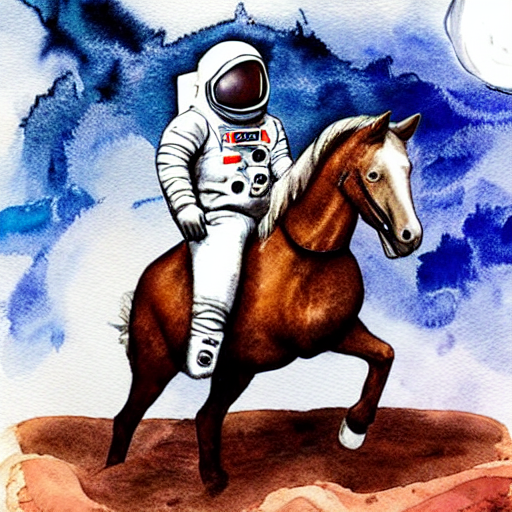

In [ ]:
prompt = "astronaut riding a horse on the moon, watercolor art"
image = pipe(prompt).images[0]
display(image)

---
### Diffuser Example

In [ ]:
# Simplified DDPM Implementation
class SimpleDDPM(nn.Module):
    """
    Simplified Denoising Diffusion Probabilistic Model
    """
    def __init__(self, timesteps=1000):
        super(SimpleDDPM, self).__init__()

        self.timesteps = timesteps

        # Noise schedule
        self.register_buffer('betas', torch.linspace(0.0001, 0.02, timesteps))
        self.register_buffer('alphas', 1.0 - self.betas)
        self.register_buffer('alpha_bars', torch.cumprod(self.alphas, dim=0))

        # Simple U-Net for denoising
        self.unet = SimpleUNet()

    def forward_process(self, x0, t):
        """Add noise to clean image x0 at timestep t"""
        noise = torch.randn_like(x0)
        alpha_bar_t = self.alpha_bars[t].reshape(-1, 1, 1, 1)

        xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
        return xt, noise

    def reverse_process(self, xt, t):
        """Predict noise to remove from xt"""
        return self.unet(xt, t)

    def training_loss(self, x0):
        """Compute training loss"""
        batch_size = x0.shape[0]
        t = torch.randint(0, self.timesteps, (batch_size,), device=x0.device)

        xt, noise = self.forward_process(x0, t)
        predicted_noise = self.reverse_process(xt, t)

        loss = F.mse_loss(predicted_noise, noise)
        return loss

class SimpleUNet(nn.Module):
    """
    Simplified U-Net for diffusion models
    """
    def __init__(self, in_channels=3, out_channels=3, time_emb_dim=128):
        super(SimpleUNet, self).__init__()

        # Time embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # Encoder
        self.conv1 = nn.Conv2d(in_channels, 64, 3, 1, 1)
        self.conv2 = nn.Conv2d(64, 128, 3, 1, 1)

        # Decoder
        self.conv3 = nn.Conv2d(128 + time_emb_dim, 64, 3, 1, 1)
        self.conv4 = nn.Conv2d(64, out_channels, 3, 1, 1)

    def positional_encoding(self, t, dim):
        """Create positional encoding for timesteps"""
        half_dim = dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

    def forward(self, x, t):
        # Time embedding
        t_emb = self.positional_encoding(t.float(), 128)
        t_emb = self.time_mlp(t_emb)

        # Encoder
        h1 = F.relu(self.conv1(x))
        h2 = F.relu(self.conv2(h1))

        # Add time embedding
        b, c, h, w = h2.shape
        t_emb = t_emb.view(b, -1, 1, 1).expand(b, -1, h, w)
        h2_with_time = torch.cat([h2, t_emb], dim=1)

        # Decoder
        h3 = F.relu(self.conv3(h2_with_time))
        output = self.conv4(h3)

        return output

/tmp/ipython-input-2708813919.py:20: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  axes[0].imshow(dummy_images[0].T)


DDPM training loss: 0.9749
Original image shape: torch.Size([1, 3, 64, 64])
Noisy image shape: torch.Size([2, 3, 64, 64])


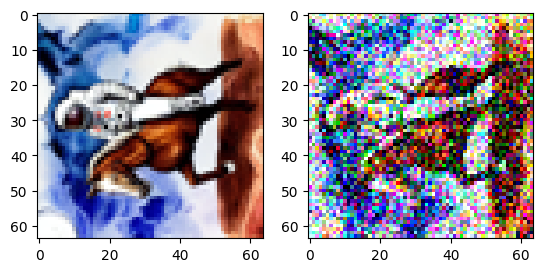

In [ ]:
from torchvision.transforms import ToTensor

img = ToTensor()(image.resize((64,64)))

# Demonstrate DDPM
ddpm = SimpleDDPM()
dummy_images = img.reshape(1, 3, 64, 64)

# Training step
loss = ddpm.training_loss(dummy_images)
print(f"DDPM training loss: {loss.item():.4f}")

# Forward process demonstration
t = torch.tensor([100, 500])
noisy_images, noise = ddpm.forward_process(dummy_images, t)
print(f"Original image shape: {dummy_images.shape}")
print(f"Noisy image shape: {noisy_images.shape}")

fig, axes = plt.subplots(1, 2)
axes[0].imshow(dummy_images[0].T)
axes[1].imshow(noisy_images[0].T)
plt.show()

---
## 5. Flow-Based Models (Normalizing Flows):

**Key Concepts:**
1. Invertible transformations between data and latent space
2. Exact likelihood computation
3. Bijective mappings with tractable Jacobians
4. Examples: RealNVP, Glow, Flow++

**Advantages:**
- Exact likelihood estimation
- Stable training (no mode collapse)
- Bidirectional generation and inference

**In Multi-Modal Context:**
- Cross-modal generation
- Exact probability estimates
- Controllable generation
- Style transfer applications

**Popular Architectures:**
- Coupling layers (RealNVP)
- Autoregressive flows
- Continuous normalizing flows (CNFs)

References:
- [RealNVP Blog](https://bjlkeng.io/posts/normalizing-flows-with-real-nvp/)
- [RealNVP Implementation](https://github.com/bjlkeng/sandbox/blob/master/realnvp/pytorch-realnvp-cifar10.ipynb)

## Key Takeaways

### 1. Multi-Modal AI Systems
- Combine multiple data modalities for richer understanding
- Require careful alignment and fusion strategies
- Enable more human-like AI interactions

### 2. Vision-Language Models (VLMs)
- Bridge computer vision and NLP
- Enable zero-shot capabilities through joint training
- Applications: captioning, VQA, retrieval

### 3. Audio Models
- ASR: Speech-to-text conversion
- TTS: Text-to-speech synthesis
- Critical for natural human-AI interaction

### 4. Diffusion Models
- State-of-the-art for image generation
- Text conditioning enables controllable generation
- DDPM and Stable Diffusion are key architectures

### 5. Flow-Based Models
- Provide exact likelihood estimation
- Invertible transformations
- Useful for cross-modal generation


## End-to-end multi-modal pipeline demo

In [ ]:
class EndToEndMultiModal(nn.Module):
    """
    Complete multi-modal system combining all concepts
    """
    def __init__(self):
        super(EndToEndMultiModal, self).__init__()

        # Core components
        self.clip = CustomCLIP()
        self.audio_encoder = AudioFeatureExtractor()

        # Task-specific heads
        self.classifier = nn.Linear(512 * 3, 100)  # 100 classes
        self.generator = nn.Linear(512 * 3, 784)   # Generate 28x28 images

    def encode_all_modalities(self, images, texts, audio):
        """Encode all three modalities"""
        img_feat = self.clip.encode_image(images)
        text_feat = self.clip.encode_text(texts)
        audio_feat = self.audio_encoder(audio)

        return torch.cat([img_feat, text_feat, audio_feat], dim=1)

    def classify(self, images, texts, audio):
        """Multi-modal classification"""
        features = self.encode_all_modalities(images, texts, audio)
        return self.classifier(features)

    def generate(self, condition_features):
        """Generate content based on multi-modal conditions"""
        return torch.sigmoid(self.generator(condition_features))

# Final demo
print("End-to-End Multi-Modal System Demo:")
e2e_model = EndToEndMultiModal()

# Sample inputs
sample_images = torch.randn(2, 3, 224, 224)
sample_texts = torch.randint(0, 1000, (2, 15))
sample_audio = torch.randn(2, 80, 200)

# Multi-modal classification
classifications = e2e_model.classify(sample_images, sample_texts, sample_audio)
print(f"Multi-modal classification: {classifications.shape}")

# Feature encoding
all_features = e2e_model.encode_all_modalities(sample_images, sample_texts, sample_audio)
print(f"Combined features: {all_features.shape}")

# Generation
generated_content = e2e_model.generate(all_features)
print(f"Generated content: {generated_content.shape}")

End-to-End Multi-Modal System Demo:
Multi-modal classification: torch.Size([2, 100])
Combined features: torch.Size([2, 1536])
Generated content: torch.Size([2, 784])
